# Chowdeck — EDA

Phân tích khám phá dữ liệu (EDA), trả lời Business Question #1–6. Cần chạy 01a_chowdeck_cleaning trước.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)

## ĐƯỜNG DẪN

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent
CLEAN_PATH = BASE_DIR / 'data' / 'clean' / 'chowdeck_clean.csv'
CHARTS_DIR = BASE_DIR / 'outputs' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH

In [3]:
# Cần chạy 01a_chowdeck_cleaning trước để có file này
df_clean = pd.read_csv(CLEAN_PATH, parse_dates=['Order Received', 'Order Delivered'])
print("Shape dữ liệu đã làm sạch:", df_clean.shape)

Shape dữ liệu đã làm sạch: (3061, 33)


## Q1: NHÀ HÀNG NÀO TẠO DOANH THU & AOV CAO NHẤT?


=== Top 10 nhà hàng theo doanh thu ===
                    total_orders  total_revenue  aov_restaurant  aov_customer  \
Shop Name                                                                       
Tasty Bites                  207        2293000    11077.294686  12457.367150   
Mama Cass Kitchen            192        2176500    11335.937500  12721.994792   
Naija Kitchen                188        2143000    11398.936170  12818.643617   
Kulture Kitchen              200        2139000    10695.000000  12046.105000   
Lekki Eats                   198        2123000    10722.222222  12140.429293   
Sweet Bites Bakery           214        1947000     9098.130841  10208.822430   
Oven Fresh                   211        1915000     9075.829384  10193.004739   
BakeHouse                    202        1785000     8836.633663   9955.039604   
Golden Crust                 216        1768500     8187.500000   9276.203704   
Sunrise Bakery               182        1405000     7719.780220   881

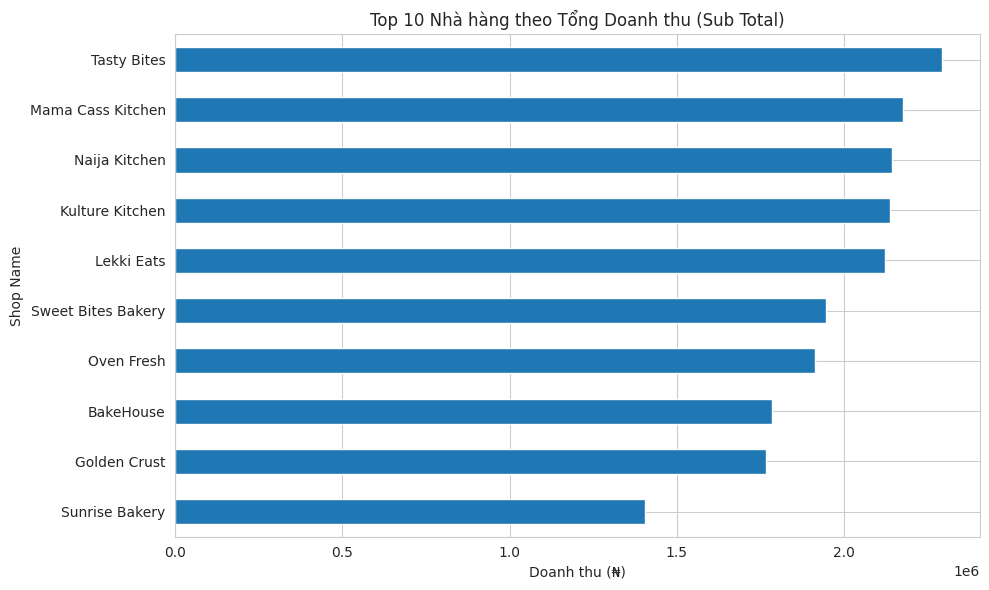

In [4]:
shop_stats = df_clean.groupby('Shop Name').agg(
    total_orders=('revenue', 'count'),
    total_revenue=('revenue', 'sum'),
    aov_restaurant=('revenue', 'mean'),
    aov_customer=('Total', 'mean'),
    avg_rating=('Rating', 'mean')
).sort_values('total_revenue', ascending=False)
print("\n=== Top 10 nhà hàng theo doanh thu ===")
print(shop_stats.head(10))

plt.figure(figsize=(10, 6))
shop_stats['total_revenue'].head(10).plot(kind='barh')
plt.title('Top 10 Nhà hàng theo Tổng Doanh thu (Sub Total)')
plt.xlabel('Doanh thu (₦)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_top10_shops_revenue.png', dpi=120)
plt.show()
plt.close()

## Q2: NHÓM MÓN ĂN NÀO ĐÓNG GÓP DOANH THU NHIỀU NHẤT?


=== Doanh thu theo Order Category ===
Order Category
Food                  10874500
Pastries               8820500
Drinks & Beverages     5531000
Name: revenue, dtype: int64


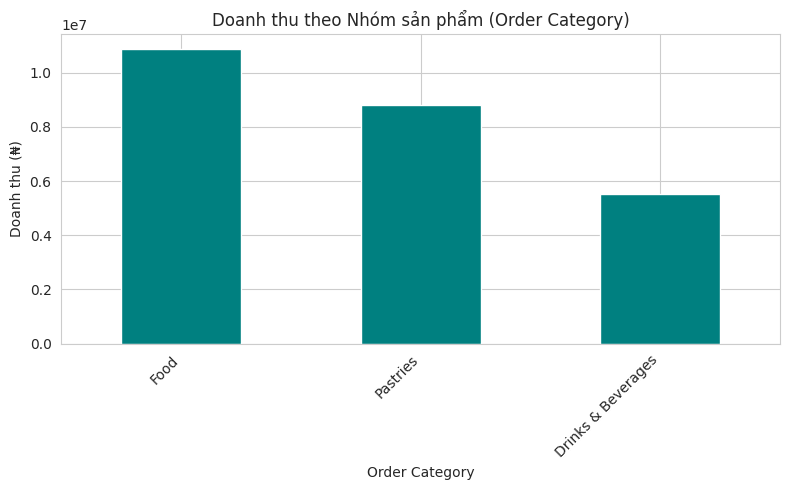

In [5]:
category_revenue = df_clean.groupby('Order Category')['revenue'].sum().sort_values(ascending=False)
print("\n=== Doanh thu theo Order Category ===")
print(category_revenue)

plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar', color='teal')
plt.title('Doanh thu theo Nhóm sản phẩm (Order Category)')
plt.ylabel('Doanh thu (₦)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_revenue_by_category.png', dpi=120)
plt.show()
plt.close()

## Q3: RATING CÓ LIÊN HỆ VỚI SỐ ĐƠN / AOV KHÔNG? (cấp nhà hàng)


Tương quan Rating trung bình vs Số đơn hàng (theo nhà hàng): 0.052
Tương quan Rating trung bình vs AOV nhà hàng (theo nhà hàng): 0.137


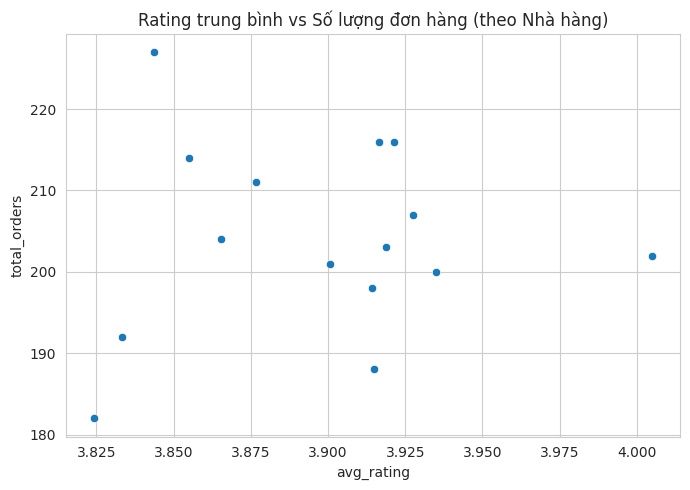

In [6]:
corr_rating_orders = shop_stats['avg_rating'].corr(shop_stats['total_orders'])
corr_rating_aov = shop_stats['avg_rating'].corr(shop_stats['aov_restaurant'])
print(f"\nTương quan Rating trung bình vs Số đơn hàng (theo nhà hàng): {corr_rating_orders:.3f}")
print(f"Tương quan Rating trung bình vs AOV nhà hàng (theo nhà hàng): {corr_rating_aov:.3f}")

plt.figure(figsize=(7, 5))
sns.scatterplot(data=shop_stats, x='avg_rating', y='total_orders')
plt.title('Rating trung bình vs Số lượng đơn hàng (theo Nhà hàng)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_rating_vs_orders.png', dpi=120)
plt.show()
plt.close()

## Q4: THỜI GIAN GIAO HÀNG/CHUẨN BỊ MÓN CÓ LIÊN HỆ VỚI RATING?

In [7]:
corr_delivery_rating = df_clean['delivery_time_min'].corr(df_clean['Rating'])
corr_prep_rating = df_clean['prep_time_min'].corr(df_clean['Rating'])
print(f"\nTương quan Thời gian giao hàng vs Rating (cấp đơn hàng): {corr_delivery_rating:.3f}")
print(f"Tương quan Thời gian chuẩn bị món vs Rating (cấp đơn hàng): {corr_prep_rating:.3f}")


Tương quan Thời gian giao hàng vs Rating (cấp đơn hàng): 0.046
Tương quan Thời gian chuẩn bị món vs Rating (cấp đơn hàng): -0.017


## Q5: KHU VỰC NÀO CÓ DOANH THU & MẬT ĐỘ ĐƠN CAO NHẤT?

In [8]:
location_stats = df_clean.groupby('Delivery Location').agg(
    total_orders=('revenue', 'count'),
    total_revenue=('revenue', 'sum')
).sort_values('total_revenue', ascending=False)
print("\n=== Doanh thu theo Khu vực giao hàng ===")
print(location_stats)


=== Doanh thu theo Khu vực giao hàng ===
                    total_orders  total_revenue
Delivery Location                              
Adeniran Ogunsanya           333        2714500
Anthony                      310        2696500
Ikeja                        296        2660500
Oshodi                       319        2647500
Mushin                       303        2638000
Surulere                     318        2520500
Yaba                         306        2438000
Maryland                     304        2351500
Ojota                        293        2290500
Ogba                         279        2268500


## Q6: KHUNG GIỜ/NGÀY NÀO TẠO DOANH THU CAO NHẤT?

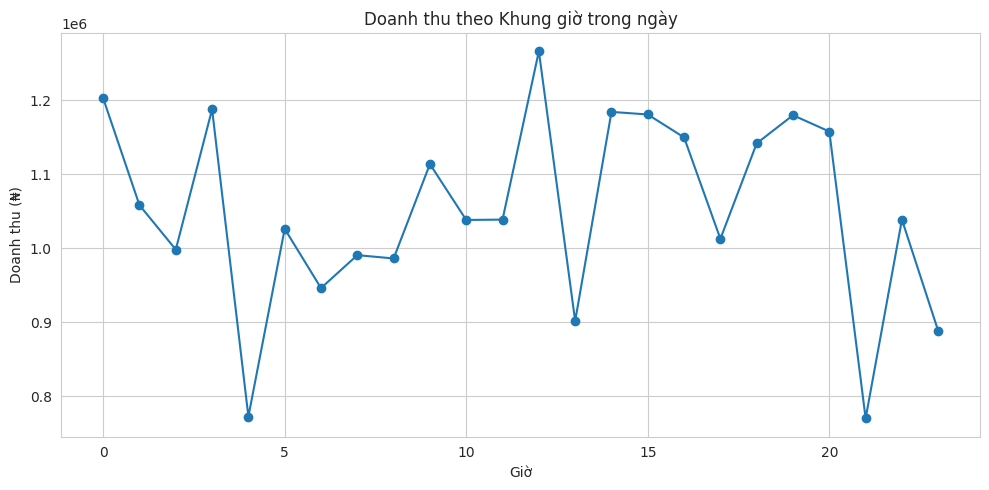

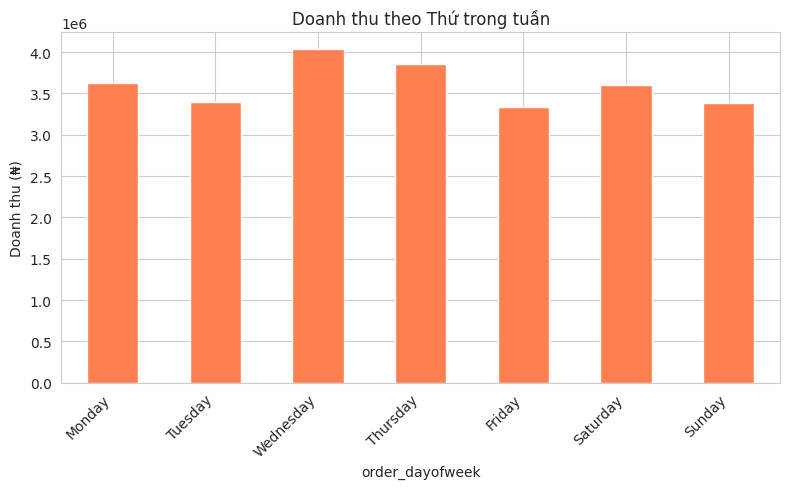


=== HOÀN TẤT EDA CHOWDECK ===
Các biểu đồ đã lưu vào outputs/charts/


In [9]:
hourly_revenue = df_clean.groupby('order_hour')['revenue'].sum()
dow_revenue = df_clean.groupby('order_dayofweek')['revenue'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(10, 5))
hourly_revenue.plot(kind='line', marker='o')
plt.title('Doanh thu theo Khung giờ trong ngày')
plt.xlabel('Giờ')
plt.ylabel('Doanh thu (₦)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_revenue_by_hour.png', dpi=120)
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
dow_revenue.plot(kind='bar', color='coral')
plt.title('Doanh thu theo Thứ trong tuần')
plt.ylabel('Doanh thu (₦)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_revenue_by_dayofweek.png', dpi=120)
plt.show()
plt.close()

print("\n=== HOÀN TẤT EDA CHOWDECK ===")
print("Các biểu đồ đã lưu vào outputs/charts/")